# Grundlagen der Künstlichen Intelligenz.
# Exercise 3. Machine Learning Methods

**Autor:** Arturo Olivares Martos
***

- **Asignatura:** Grundlagen der Künstlichen Intelligenz.
- **Curso Académico:** 2025-26.
- **Grado:** Doble Grado en Ingeniería Informática y Matemáticas.
- **Grupo:** Erasmus.
- **Profesor:** Gérald Kämmerer
- **Descripción:** Práctica 3 de la asignatura GKI
<!--- **Fecha:** 17 de abril de 2023. -->
<!-- - **Duración:** -->

##  Data Generation and Visualization

### Data Generation

- Use the `make_blobs` function from `sklearn.datasets` to generate a synthetic dataset with 5 centers and `cluster_std=0.8`.
- Split the dataset into training and test data (400 training data points, 100 test data points).

In [2]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split


random_state = 42

# X: array of shape (n_samples, n_features) with the generated samples.
# y: array of shape (n_samples,) with the integer labels for cluster membership of each sample.
# X[i] is the i-th sample and y[i] is the integer label for cluster membership of X[i].
X, y = make_blobs(
    n_samples=500,              # Total number of samples to generate. They will have two features (n_features=2), so they can be visualized in a 2D scatter plot.
    centers=5,                  # The number of centers to generate, or the fixed center locations. In this case, we want 5 clusters.
    cluster_std=0.8,            # The standard deviation of the clusters.
    random_state=random_state   # Controls the randomness of the generated data. Setting it to a fixed value ensures reproducibility of the results.
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

print(f"Training data size: {len(X_train)}")
print(f"Test data size: {len(X_test)}")

Training data size: 400
Test data size: 100


### Data Visualization

- Use `seaborn` and `matplotlib` to display the training and test data in a scatter plot.
- Use different markers and colors to visualize the cluster assignments.
- Nice to Have: Label the axes and add a title.

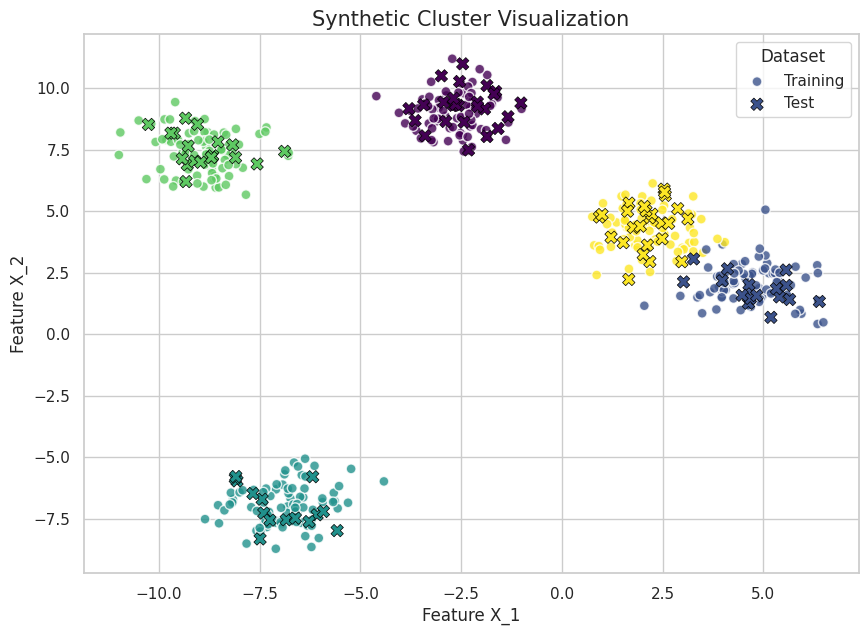

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 7))

# 1. Plot training data (Large circles)
scatter_train = plt.scatter(
    X_train[:, 0], X_train[:, 1], # X-Axis: Feature 1, Y-Axis: Feature 2
    c=y_train,                # Color depending on the cluster
    cmap='viridis',           # Color palette
    marker='o',
    s=50,
    label='Training',
    edgecolor='w',
    alpha=0.8
)

# 2. Plot test data (Visible crosses)
scatter_test = plt.scatter(
    X_test[:, 0], X_test[:, 1], # X-Axis: Feature 1, Y-Axis: Feature 2
    c=y_test,                 # Color depending on the cluster
    cmap='viridis',           # Same color palette to match training data
    marker='X',               # Different marker for test data
    s=80,                     # Slightly larger size to highlight
    label='Test',
    edgecolor='black',
    linewidth=0.5
)

plt.title('Synthetic Cluster Visualization', fontsize=15)
plt.xlabel('Feature X_1', fontsize=12)
plt.ylabel('Feature X_2', fontsize=12)
plt.legend(title='Dataset')

plt.show()

## kNN with Scikit-learn

### kNN Classifier

- Import `KNeighborsClassifier` from `sklearn.neighbors`.
- Initialize a kNN classifier with `k=8` using the constructor `KNeighborsClassifier(n_neighbors=8)`.
- Train the classifier with the training data using the `fit(X_train, y_train)` method and predict the groups of the test data. Use the `predict(X_test)` method to make predictions for the test data.

In [4]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

### Evaluation

- Calculate the Adjusted Rand Index (ARI) using the function `adjusted_rand_score(y_test, y_pred)` from `sklearn.metrics`.
- Calculate the Adjusted Mutual Information (AMI) using the function `adjusted_mutual_info_score(y_test, y_pred)` from `sklearn.metrics`.

In [ ]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
ari_score = adjusted_rand_score(y_test, y_pred)
ami_score = adjusted_mutual_info_score(y_test, y_pred)

print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")
print(f"Adjusted Mutual Information (AMI): {ami_score:.4f}")

# // TODO: Qué representan?

Adjusted Rand Index (ARI): 0.9750
Adjusted Mutual Information (AMI): 0.9733


### Visualization of Results

- Create a function that visualizes the training data and the predicted test data.
-  Use the same colors as in the first visualization to represent the cluster assignments. What differences do you notice? Which points are misclassified?

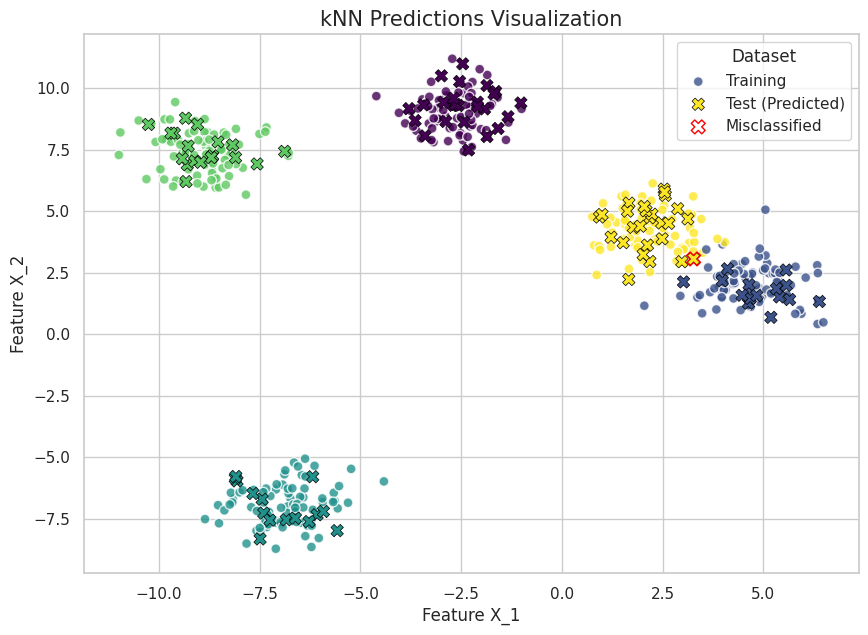

In [9]:
def plot_predictions(X_train, y_train, X_test, y_test, y_pred, title='kNN Predictions Visualization'):
    """
    Visualizes the training data and the predicted test data.
    Training data is shown as circles, and test data is shown as crosses.
    Colors represent the cluster assignments.
    Parameters:
    - X_train: Training data features
    - y_train: Training data labels
    - X_test: Test data features
    - y_test: Test data true labels (for reference)
    - y_pred: Test data predicted labels
    - title: Title of the plot
    """
    plt.figure(figsize=(10, 7))

    # Plot training data
    plt.scatter(
        X_train[:, 0], X_train[:, 1],
        c=y_train,
        cmap='viridis',
        marker='o',
        s=50,
        label='Training',
        edgecolor='w',
        alpha=0.8
    )

    # Plot test data with predicted labels
    plt.scatter(
        X_test[:, 0], X_test[:, 1],
        c=y_pred,
        cmap='viridis',
        marker='X',
        s=80,
        label='Test (Predicted)',
        edgecolor='black',
        linewidth=0.5
    )

    # Mark misclassified points with a red edge
    misclassified = y_test != y_pred
    plt.scatter(
        X_test[misclassified][:, 0], X_test[misclassified][:, 1],
        facecolors='none', edgecolors='red',
        marker='X', s=100, label='Misclassified'
    )

    plt.title('kNN Predictions Visualization', fontsize=15)
    plt.xlabel('Feature X_1', fontsize=12)
    plt.ylabel('Feature X_2', fontsize=12)
    plt.legend(title='Dataset')

    plt.show()

plot_predictions(X_train, y_train, X_test, y_test, y_pred)

## Own kNN Implementation

### Euclidean Distance

Implement a function to calculate the Euclidean distance

$$\sqrt{\Delta x^2 + \Delta y^2}$$

between two points.

In [10]:
import numpy as np
def euclidean_distance(point1, point2):
    """
    Calculate the Euclidean distance between two points in 2D space.
    Parameters:
    - point1: A list or array with two elements representing the coordinates of the first point (x1, y1).
    - point2: A list or array with two elements representing the coordinates of the second point (x2, y2).
    Returns:
    - The Euclidean distance between the two points.
    """
    return np.sqrt(np.sum((point1 - point2) ** 2))

### kNN Class

Create a class named `kNN` with the following methods:
- `__init__(self, k=8)`: Initializes the classifier.
- `fit(self, X, y)`: Stores the training data and labels.
- `predict(self, X)`: Makes predictions for new data points.
- `_predict(self, x)`: Helper method to predict for a single data point.
- `plot(self, X_test, predictions)`: Visualizes the training data and predictions.

In [11]:
class kNN:
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        y_pred = []
        for x in X:
            label = self._predict(x)
            y_pred.append(label)
        return np.array(y_pred)

    def _predict(self, x):
        # Compute distances between x and all examples in the training set
        distances = []
        for i, x_train in enumerate(self.X_train):
            dist = euclidean_distance(x, x_train)
            distances.append((dist, self.y_train[i]))

        # Sort by distance and return the labels of the k nearest neighbors
        distances.sort(key=lambda x: x[0])
        neighbors = distances[:self.k]
        neighbor_labels = [label for _, label in neighbors]

        # Return the most common class label among the neighbors
        return max(set(neighbor_labels), key=neighbor_labels.count)
    
    def plot(self, X_test, predictions, y_test=None):
        plt.figure(figsize=(10, 7))

        # Plot training data
        plt.scatter(
            self.X_train[:, 0], self.X_train[:, 1],
            c=self.y_train,
            cmap='viridis',
            marker='o',
            s=50,
            label='Training',
            edgecolor='w',
            alpha=0.8
        )

        # Plot test data with predicted labels
        plt.scatter(
            X_test[:, 0], X_test[:, 1],
            c=predictions,
            cmap='viridis',
            marker='X',
            s=80,
            label='Test (Predicted)',
            edgecolor='black',
            linewidth=0.5
        )

        if y_test is not None:
            # Mark misclassified points with a red edge
            misclassified = y_test != predictions
            plt.scatter(
                X_test[misclassified][:, 0], X_test[misclassified][:, 1],
                facecolors='none', edgecolors='red',
                marker='X', s=100, label='Misclassified'
            )


        plt.title('kNN Predictions Visualization', fontsize=15)
        plt.xlabel('Feature X_1', fontsize=12)
        plt.ylabel('Feature X_2', fontsize=12)
        plt.legend(title='Dataset')

        plt.show()

### Predictions with Own Implementation

- Initialize a kNN object with `k=8`.
- Train the classifier with the training data.
- Make predictions for the test data.

In [12]:
knn_custom = kNN(k=8)
knn_custom.fit(X_train, y_train)
y_pred_custom = knn_custom.predict(X_test)

### Evaluation

- Calculate the ARI and AMI for the predictions of your own implementation.
- Print the results and compare them with `Scikit-learn`.

In [16]:
ari_score_custom = adjusted_rand_score(y_test, y_pred_custom)
ami_score_custom = adjusted_mutual_info_score(y_test, y_pred_custom)
print(f"Adjusted Rand Index (ARI):\n\t- Custom Implementation: {ari_score_custom:.4f}\n\t- Scikit-learn: {ari_score:.4f}")
print(f"Adjusted Mutual Information (AMI):\n\t- Custom Implementation: {ami_score_custom:.4f}\n\t- Scikit-learn: {ami_score:.4f}")

Adjusted Rand Index (ARI):
	- Custom Implementation: 0.9750
	- Scikit-learn: 0.9750
Adjusted Mutual Information (AMI):
	- Custom Implementation: 0.9733
	- Scikit-learn: 0.9733


### Visualization of Results

- Use the plot method of your kNN class to visualize the results.
- Compare the visualization with the one from Part 2.

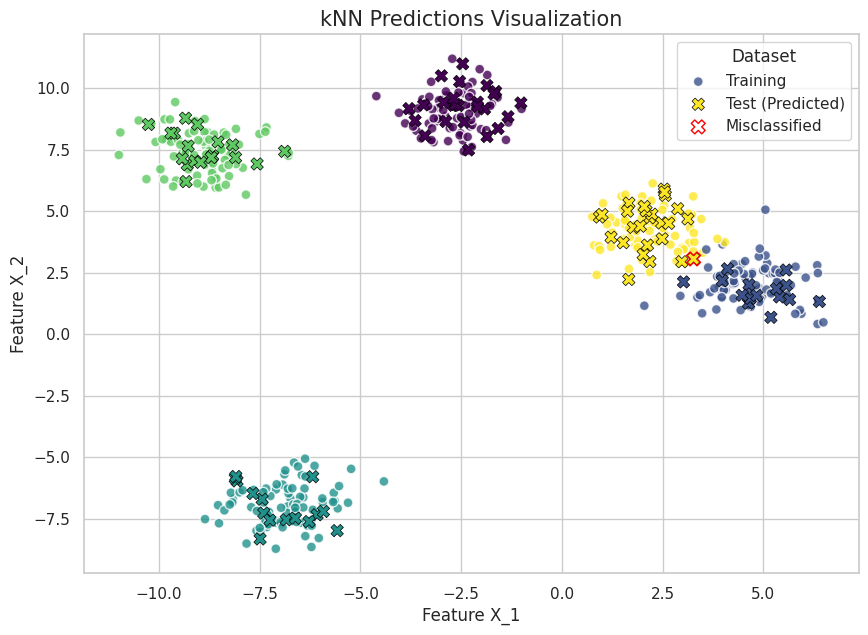

In [17]:
knn_custom.plot(X_test, y_pred_custom, y_test)